ZIELE:


## Zeitbereich & Diskretisierung

1. ABTASTRATE (Sampling Rate $f_s$) & Nyquist-Theorem

Konzept: 
- Warum führt eine Messung mit $250\,\text{Hz}$ dazu, dass nur Signale bis $125\,\text{Hz}$ exakt dargestellt werden können? Was passiert mathematisch, wenn Frequenzen darüber liegen (Aliasing)?

Praxis: 
-  künstliche $100\,\text{Hz}$-Sinuswelle erzeugen undmit verschiedenen Frequenzen abtasten

In [115]:
# Man kann es mit math machen
import math

print(math.sin(math.radians(30)))

0.49999999999999994


<img src="../screenshots/wavefunc.png" width="660" height="90"/>

<img src="../screenshots/formel.png" width="660" height="500"/>

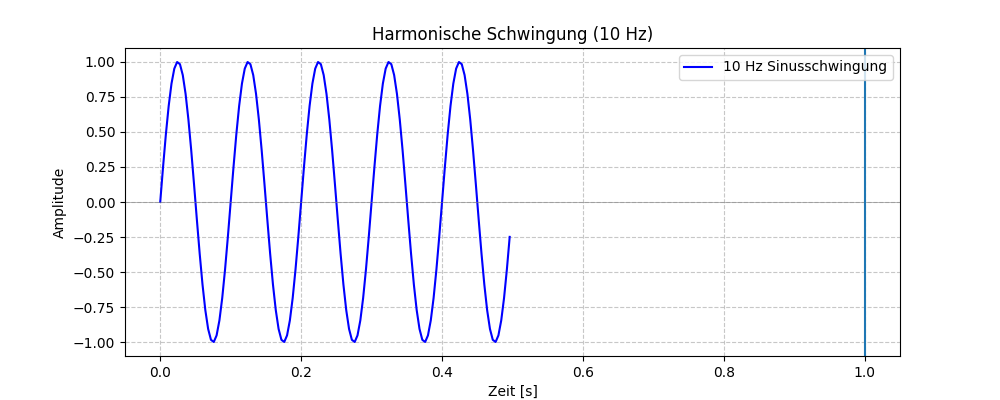

In [116]:
import numpy as np
import matplotlib.pylab as plt

#--- Params
freq = 10 #Hz
amplitude = 1 #The units of amplitude are arbitrary, usually chosen so
# 1.0 corresponds to the maximum input
dauer = 0.5
abtastrate = 250 # Hz

# np.linspace(start, stop, num= ): 
# return evenly spaced numbers over a specified interval
t = np.linspace(0, dauer, int(abtastrate * dauer), endpoint=False)

# Schwingung berechnen (y)
#
# sin() erwartet Arg in Radiant (Winkel im Bogenmass)
# 1 vollst. Schwingung = 2pi (1 Umdrehung)
y = amplitude * np.sin(2 * np.pi * freq * t)


plt.figure(figsize=(10, 4))
plt.plot(t, y, label=f"{freq} Hz Sinusschwingung", color="b")
plt.title(f"Harmonische Schwingung ({freq} Hz)")
plt.xlabel("Zeit [s]")
plt.ylabel("Amplitude")
plt.grid(True, linestyle="--", alpha=0.7)
plt.axhline(0, color="grey", linewidth=0.4)
plt.axvline(1)
plt.legend(loc="upper right")
plt.show()

einen (Resonate & Fire) neuron implementieren der in einem EEG Signal bestimmte Frequenzen erkennen kann
ich wurde Augen zu Signal ausprobieren und versuchen da 10Hz zu erkennen

- 10Hz, 10.5Hz, 11Hz 
- w = 2*pi*f
- lambda = e^(b+iw)*delta_t

delta_t = 1 \ Abtastrate

![WARUM SIEHT ES SO KOMISCH AUS](../screenshots/rf_formel.png)

In [117]:
# y sind die Werte der Welle
import cmath

def get_w(freq):
    return (2 * math.pi  * freq)

def get_lambda(w):
    daempfung = -3
    delta_t = 1 / abtastrate  
    return (cmath.exp (complex(daempfung, w)*delta_t))

def ampl(z):
    return (abs(z))

w_10 = get_w(10)
w_20 = get_w(10.2)

l_10hz = get_lambda(w_10)
l_20hz = get_lambda(w_20)

z_10, z_20 = 0, 0
for i in range(len(y)):
    z_10 = l_10hz * z_10 + y[i]
    z_20 = l_20hz * z_20 + y[i]
print('10 Hz: ', z_10, ampl(z_10))
print('20 Hz: ', z_20,ampl(z_20))

10 Hz:  (-8.883602252893994-31.522769733197123j) 32.75062443129584
20 Hz:  (-1.3256647918920286-31.930053151531112j) 31.957560629686117


ok das hat geklappt, jetzt mit dem echten Signal, Augen zu Datenset


"Wenn Sie eine reelle Zahl wie $1$ mit $i$ multiplizieren, erhalten Sie $i$. Geometrisch wandern Sie von der X-Achse $(1, 0)$ zur Y-Achse $(0, 1)$ – das ist eine 90°-Rotation. Multiplizieren Sie erneut mit $i$, erhalten Sie $i \cdot i = i^2 = -1$. Sie landen bei $(-1, 0)$ auf der X-Achse – wieder eine 90°-Rotation. Die Multiplikation mit $i$ ist geometrisch also nichts anderes als ein Operator für eine 90°-Drehung gegen den Uhrzeigersinn."


In [118]:
import pandas as pd
augen_zu = pd.read_csv('../data/sanity-checks/gel augen zu besser/augen_zu.csv')
print(augen_zu[' EEG 8'])
eeg_7 = augen_zu[' EEG 8']

freq1 = 11
freq2 = 11.5
w_1 = get_w(freq1)
w_2 = get_w(freq2)

l_1hz = get_lambda(w_1)
l_2hz = get_lambda(w_2)

z_1, z_2 = 0, 0
for i in range(len(eeg_7)):
    z_1 = l_1hz * z_1 + eeg_7[i]
    z_2 = l_2hz * z_2 + eeg_7[i]
print(z_1)
print(f'{freq1} Hz: ', z_1, ampl(z_1))
print(f'{freq2} Hz: ', z_2, ampl(z_2))

0        0.000
1        0.000
2        0.000
3        0.000
4        0.000
         ...  
20867    9.910
20868    7.897
20869    5.958
20870    4.956
20871    5.175
Name:  EEG 8, Length: 20872, dtype: float64
(54.956072573472795+133.43506963103732j)
11 Hz:  (54.956072573472795+133.43506963103732j) 144.3090008285713
11.5 Hz:  (-1.9108770981183385+185.3158629700949j) 185.32571467455648


[ 2.5  5.  10.  20. ]
Spike! (416.4500291091629+8.423371073176973j)
DANACH! (0.009997955049291291+0.00020222470756761185j)
Spike! (424.8839418579571+31.495792069003517j)
DANACH! (0.009972637920036989+0.0007392515917063069j)
Spike! (572.9747053193211+9.560888641930616j)
DANACH! (0.009998608109907998+0.00016684083577451982j)
Spike! (404.0066628451752+7.57134779424372j)
DANACH! (0.0099982444024623+0.00018737360708306593j)
Spike! (411.98002742271194+21.071972825692296j)
DANACH! (0.00998694499719466+0.0005108127083467638j)
Spike! (507.97850210521386+10.342903004206377j)
DANACH! (0.009997927811617489+0.00020356687767310072j)
Spike! (386.8089177957682+11.136177087155303j)
DANACH! (0.00999585829243025+0.0002877794253476513j)
Spike! (483.5890816973021+41.545009241014576j)
DANACH! (0.009963300608183456+0.0008559445022728625j)
Spike! (390.08652290005546+7.329369888412827j)
DANACH! (0.009998235318142703+0.0001878577202136156j)
Spike! (364.07268988806385+35.662212857653756j)
DANACH! (0.009952368004

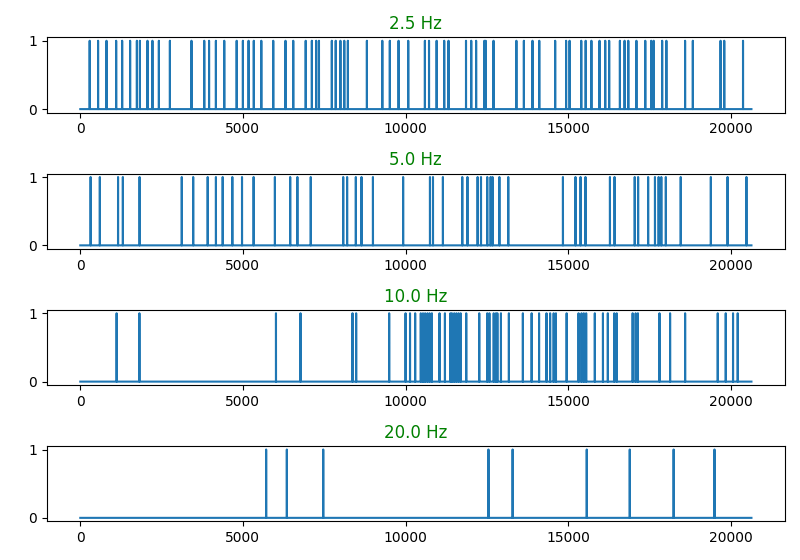

In [257]:
import numpy as np
import pandas as pd


class RFLayer:
    def __init__(self, frequenzen, decays, delta_t):
        self.frequenzen = frequenzen
        self.w = 2 * np.pi * frequenzen
        self.rotation = np.exp(self.w*delta_t*1j)
        self.decay = np.full(self.frequenzen.shape, fill_value=decays)
        self.threshold = 360
        self.s_previous = np.full(self.frequenzen.shape, fill_value=(0 + 0j))
        self.s_now = np.full(self.frequenzen.shape, fill_value=(0 + 0j))
        self.spike =  np.full(self.frequenzen.shape, fill_value=0)

    def update(self, i_synaptic):
        self.s_previous = self.s_now
        self.s_now = self.decay * self.rotation * self.s_previous + i_synaptic

    
    def get_strongest(self):
        return (np.max(self.s_now), np.argmax(self.s_now))


    def dospike(self):
        for i in range(len(self.frequenzen)):

            if ((self.s_previous[i].imag > 0 and self.s_now[i].imag <= 0) or (self.s_previous[i].imag < 0 and self.s_now[i].imag >= 0)) and \
                        self.s_now[i].real >= self.threshold:
                print(f"Spike! {self.s_now[i]}")
                self.s_now[i] = 0.01 * self.s_now[i] / np.abs(self.s_now[i])
                print(f"DANACH! {self.s_now[i]}")
                self.spike[i] = 1
            else:
                self.spike[i] = 0


#frequenzen = np.arange(8, 13, 0.5)
frequenzen = np.array([2.5, 5, 10, 20])
print(frequenzen)

ABTASTRATE = 250
delta_t = 1/ABTASTRATE # Zeitschtitt der Simulation
decay = 1

layer1 = RFLayer(frequenzen, decay, delta_t)


augen_zu = pd.read_csv('../data/sanity-checks/gel augen zu besser/augen_zu.csv')
#eeg_7 = augen_zu[' EEG 8'].to_numpy()

eeg_7 = augen_zu[' EEG 8'].to_numpy()
#print(eeg_7.shape)
eeg_7 = np.trim_zeros(eeg_7)

history = np.zeros((len(eeg_7), len(frequenzen) ),
                   dtype=np.complex64)

spikes = np.zeros(shape=(len(eeg_7), len(frequenzen)))
for i in range(len(eeg_7)):
    layer1.update(eeg_7[i])
    layer1.dospike()
    spikes[i, :] = layer1.spike
    history[i] = np.where(layer1.spike == 0, layer1.s_now, 0)
   # print(layer1.s_now)
    layer1.get_strongest()
#print(history)   
#TODO NEXT: fuer jedes Channel visualisieren

import matplotlib.pyplot as plt

print(history.shape)
fig, axs = plt.subplots(len(frequenzen), 1,  figsize=(8, 1.4 * len(frequenzen)))
for i in range(len(axs)):
  #axs[i].plot(np.abs(history[:,i])) 
  axs[i].plot(spikes[:,i]) 
  axs[i].set_title(f"{frequenzen[i]} Hz", color="green")
  print(history[i])
  #axs[i].set_ylim(400)
fig.tight_layout() 

    

Das scheint in die richtige Richtung zu gehen, ABER:
- DC Offset wurde entfernt (Verarbeitung auf bereinigsten Daten) - weniger interessant fuer Echtzeit-Anwendungen

JETZT WILL ICH:
- fuer bereinigte Daten die Drehung auf der komplexen Ebene visualisieren - zB nur fuer 11 Hz, und zwar in 3D sodass ich diese Abbildung routueren kann


[ 8.   8.5  9.   9.5 10.  10.5 11.  11.5 12.  12.5]
Spike! (3566.828048935643+126.32085762699036j)
DANACH! (0.00999373461898542+0.00035393271294462673j)
Spike! (3664.8529686345128+132.4345274048628j)
DANACH! (0.00999347719702372+0.0003611281110172955j)
Spike! (3639.005799626368+55.612683077335475j)
DANACH! (0.009998832448243877+0.00015280599446823036j)
Spike! (3632.7178870887687+33.87211058342405j)
DANACH! (0.009999565326804783+9.32377335822081e-05j)
Spike! (3739.4707104181907+309.48823869394084j)
DANACH! (0.009965926720706593+0.0008248057938123117j)
Spike! (3562.3026048285815+369.4853891805829j)
DANACH! (0.009946639981585874+0.001031674889060204j)
Spike! (3617.7713191010444+138.85388665186946j)
DANACH! (0.009992642600049928+0.0003835281836677144j)
Spike! (3563.9404004093244+264.3629689314479j)
DANACH! (0.009972601758710372+0.0007397392528227632j)
Spike! (3765.2305852617897+316.1801682943169j)
DANACH! (0.009964927506249135+0.000836791368979984j)
Spike! (3587.5265740256486+170.523443848

c:\Users\Dascha\Desktop\unicorn-hybrid-black-new\.mi-bci\lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\Dascha\Desktop\unicorn-hybrid-black-new\.mi-bci\lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


'for i in range(len(axs)):\n  axs[i].plot(np.abs(history[:,i])) \n  axs[i].set_title(f"{frequenzen[i]} Hz", color="green")\n  print(history[i])\n  #axs[i].set_ylim(400)\nfig.tight_layout() '

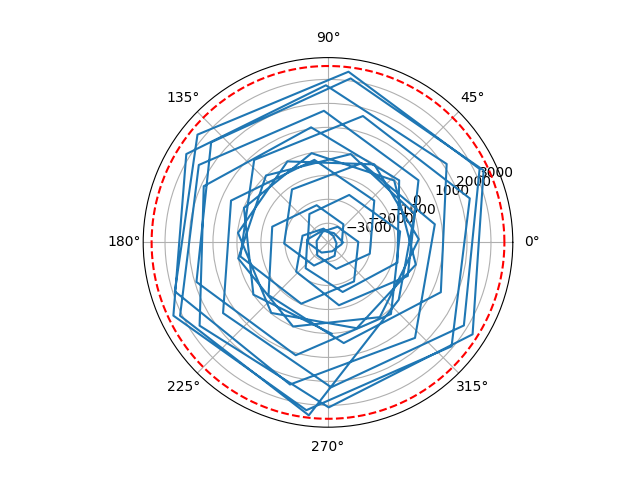

In [120]:
import numpy as np
import pandas as pd


class RFLayer:
    def __init__(self, frequenzen, decays, delta_t):
        self.frequenzen = frequenzen
        self.w = 2 * np.pi * frequenzen
        self.rotation = np.exp(self.w*delta_t*1j)
        self.decay = np.full(self.frequenzen.shape, fill_value=decays)
        self.threshold = 3560
        self.s_previous = np.full(self.frequenzen.shape, fill_value=(0 + 0j))
        self.s_now = np.full(self.frequenzen.shape, fill_value=(0 + 0j))
        self.spike =  np.full(self.frequenzen.shape, fill_value=0)

    def update(self, i_synaptic):
        self.s_previous = self.s_now
        self.s_now = self.decay * self.rotation * self.s_previous + i_synaptic

    
    def get_strongest(self):
        return (np.max(self.s_now), np.argmax(self.s_now))


    def dospike(self):
        for i in range(len(self.frequenzen)):

            if ((self.s_previous[i].imag > 0 and self.s_now[i].imag <= 0) or (self.s_previous[i].imag < 0 and self.s_now[i].imag >= 0)) and \
                        self.s_now[i].real >= self.threshold:
                print(f"Spike! {self.s_now[i]}")
                self.s_now[i] = 0.01 * self.s_now[i] / np.abs(self.s_now[i])
                print(f"DANACH! {self.s_now[i]}")
                self.spike[i] = 1
            else:
                self.spike[i] = 0


frequenzen = np.arange(8, 13, 0.5)
print(frequenzen)

ABTASTRATE = 250
delta_t = 1/ABTASTRATE # Zeitschtitt der Simulation
decay = 1    

layer1 = RFLayer(frequenzen, decay, delta_t)


augen_zu = pd.read_csv('../data/sanity-checks/gel augen zu besser/augen_zu.csv')
#eeg_7 = augen_zu[' EEG 8'].to_numpy()

eeg_7 = augen_zu[' EEG 8'].to_numpy()
#print(eeg_7.shape)
eeg_7 = np.trim_zeros(eeg_7)

history = np.zeros((len(eeg_7), len(frequenzen) ),
                   dtype=np.complex64)


#nur fuer 11Hz: index 6
for i in range(len(eeg_7)):
    layer1.update(eeg_7[i])
    layer1.dospike()
    history[i] = layer1.s_now
 
#TODO NEXT: fuer jedes Channel visualisieren
# ! threshold = 3560 
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, subplot_kw={'projection':'polar'})
ax.plot(history[9300:9400,6])

theta = np.linspace(0, 2 * np.pi, 500)
r = np.full_like(theta, 3560)
ax.plot(theta, r, color="red", linestyle="--", linewidth=1.5, label="r = 3560")

"""for i in range(len(axs)):
  axs[i].plot(np.abs(history[:,i])) 
  axs[i].set_title(f"{frequenzen[i]} Hz", color="green")
  print(history[i])
  #axs[i].set_ylim(400)
fig.tight_layout() """

    

c:\Users\Dascha\Desktop\unicorn-hybrid-black-new\.mi-bci\lib\site-packages\numpy\ma\core.py:2892: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,


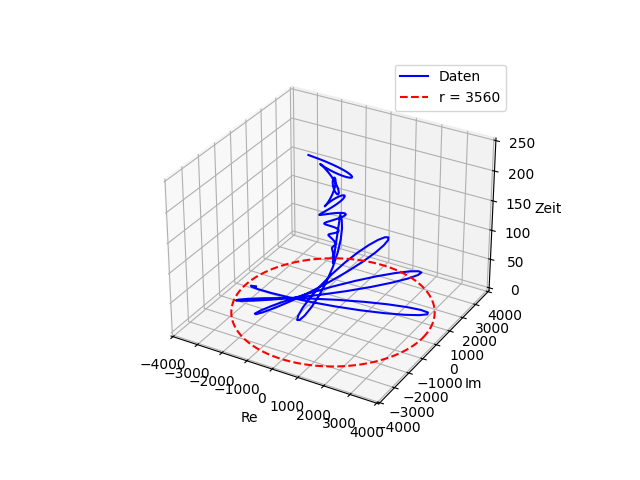

In [121]:
import matplotlib.pyplot as plt
import numpy as np

# Interaktives Backend aktivieren (WICHTIG für .ipynb)
%matplotlib widget

# Daten vorbereiten
data_r = history[9300:9550, 6]
theta_data = np.linspace(0, 2 * np.pi, len(data_r))
z_data = np.arange(len(data_r))

# Umrechnung Polar -> Kartesisch
x_data = data_r * np.cos(theta_data)
y_data = data_r * np.sin(theta_data)

# Kreis umrechnen
theta_circle = np.linspace(0, 2 * np.pi, 500)
x_circle = 3560 * np.cos(theta_circle)
y_circle = 3560 * np.sin(theta_circle)
z_circle = np.zeros_like(theta_circle)

# 3D Plot erstellen
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot(x_data, y_data, z_data, label='Daten', color='blue')
ax.plot(x_circle, y_circle, z_circle, label='r = 3560', color='red', linestyle='--')

ax.set_xlabel('Re')
ax.set_ylabel('Im')
ax.set_zlabel('Zeit')
ax.legend()

plt.show()

Scheiss drauf wie schnell ich vorankomme!

TODO: vom jedem Wert den vorherigen Wert abziehen (quasi DC Offset entfernen)

[ 8.   8.5  9.   9.5 10.  10.5 11.  11.5 12.  12.5]
Spike! (364522.7442973136+27553.912360555347j)
DANACH! (0.009971553353699415+0.0007537398187212655j)
Spike! (373364.8976801228+33963.719239612066j)
DANACH! (0.009958880447885628+0.0009059250657319003j)
Spike! (355720.986612873+87761.57020009788j)
DANACH! (0.009708883801711558+0.002395323636768714j)
Spike! (383804.38615794096+21531.488198627358j)
DANACH! (0.009984300905947725+0.0005601208972101007j)
Spike! (366883.4783283073+81775.3919493714j)
DANACH! (0.009760484234591485+0.0021755338439773935j)
Spike! (381473.1004658896+56326.054419571665j)
DANACH! (0.009892742037950888+0.0014607035875082131j)
Spike! (395527.9908696827+9544.621360885129j)
DANACH! (0.009997089662582151+0.00024124319325760098j)
Spike! (378377.5622400771+81464.12809967372j)
DANACH! (0.009775991029569074+0.00210475637302397j)
Spike! (396779.8085980122+20500.744080722023j)
DANACH! (0.009986678851938859+0.0005159898334629699j)
Spike! (398622.3629355018+21522.56768446912j)


c:\Users\Dascha\Desktop\unicorn-hybrid-black-new\.mi-bci\lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\Dascha\Desktop\unicorn-hybrid-black-new\.mi-bci\lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


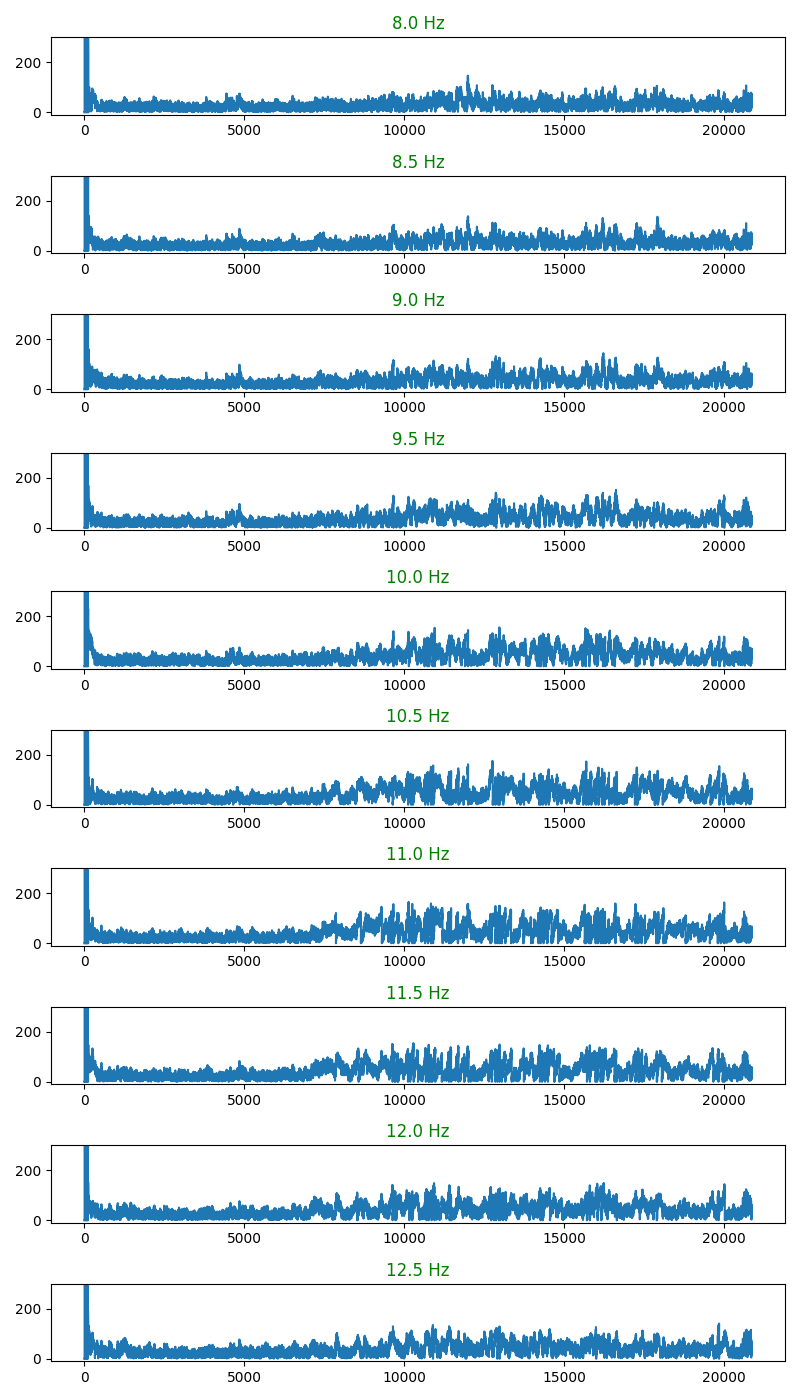

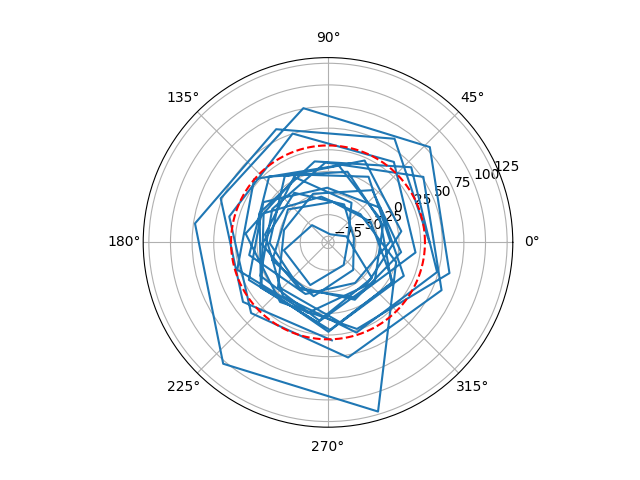

In [122]:
import numpy as np
import pandas as pd


class RFLayer:

    def __init__(self, frequenzen, decays, delta_t, baseline_decay=0.999):
        self.frequenzen = frequenzen
        self.w = 2 * np.pi * frequenzen
        self.rotation = np.exp(1j * self.w * delta_t)
        self.decay = np.full(self.frequenzen.shape, fill_value=decays)
        self.threshold = 110

        self.s_previous = np.zeros(self.frequenzen.shape, dtype=np.complex128)
        self.s_now = np.zeros(self.frequenzen.shape, dtype=np.complex128)
        self.spike = np.zeros(self.frequenzen.shape, dtype=np.int32)
        self.baseline = np.zeros(self.frequenzen.shape, dtype=np.int32) 

    def set_first_baseline(self, first_datapoint):
        self.baseline = first_datapoint
        
    def update(self, i_synaptic):

        self.s_previous = self.s_now 
        self.s_now = self.decay * self.rotation * self.s_previous + i_synaptic - self.baseline
        self.baseline = i_synaptic
        

    def dospike(self):
        for i in range(len(self.frequenzen)):

            if ((self.s_previous[i].imag > 0 and self.s_now[i].imag <= 0) or (self.s_previous[i].imag < 0 and self.s_now[i].imag >= 0)) and \
                        self.s_now[i].real >= self.threshold:
                print(f"Spike! {self.s_now[i]}")
                self.s_now[i] = 0.01 * self.s_now[i] / np.abs(self.s_now[i]) #WAS PASSIERT HIER??????? 
                # phase soll bleiben, nur die Amplitude soll gehen!
                print(f"DANACH! {self.s_now[i]}")
                self.spike[i] = 1
            else:
                self.spike[i] = 0

frequenzen = np.arange(8, 13, 0.5)
print(frequenzen)

ABTASTRATE = 250
delta_t = 1/ABTASTRATE # Zeitschtitt der Simulation
decay = 0.99  

layer1 = RFLayer(frequenzen, decay, delta_t)


augen_zu = pd.read_csv('../data/sanity-checks/gel augen zu besser/augen-zu-raw.csv')
#eeg_7 = augen_zu[' EEG 8'].to_numpy()

eeg_7 = augen_zu[' EEG 8'].to_numpy()
#print(eeg_7.shape)
eeg_7 = np.trim_zeros(eeg_7)

history = np.zeros((len(eeg_7), len(frequenzen) ),
                   dtype=np.complex64)

#print(eeg_7.shape)
for i in range(len(eeg_7)):
    if i == 0:
        layer1.set_first_baseline(eeg_7[i])
    else:
        layer1.update(eeg_7[i])
        layer1.dospike()
        history[i] = np.where(layer1.spike == 0, layer1.s_now, 0) # FUELLE ICH DAS RICHTTIG?
       
   # print(layer1.s_now)
    #layer1.get_strongest()
#print(history)   
#TODO NEXT: fuer jedes Channel visualisieren

import matplotlib.pyplot as plt

print(history.shape)
fig, axs = plt.subplots(len(frequenzen), 1,  figsize=(8, 1.4 * len(frequenzen)))
for i in range(len(axs)):
  axs[i].plot(np.abs(history[:,i])) 
  
  #axs[i].plot(np.abs(history[0:20,i])) 
  axs[i].set_title(f"{frequenzen[i]} Hz", color="green")
  axs[i].set_ylim(-10,300)
  #axs[i].set_xlim(0,1000)
                  #axs[i].set_xticks(np.arange(0,100,10))
  #axs[i].set_xlim(39)
fig.tight_layout() 

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, subplot_kw={'projection':'polar'})
ax.plot(history[9300:9400,6])

theta = np.linspace(0, 2 * np.pi, 2500)
r = np.full_like(theta, 30)
ax.plot(theta, r, color="red", linestyle="--", linewidth=1.5, label="r = 3560")

#WATAFUCKS:
# - wieso feuern alle Frequenzen exakt gleich
# - wenn ich bei diesem Versuch wo alles so aussieht als ob Neurone richtig feuern wuerden, decay auf etwas anderes als 1 
# setze funktioniert es nicht mehr 

                

![WARUM SIEHT ES SO KOMISCH AUS](../screenshots/rf_neuron.png)

----------------------------------------------------------------------------------------------------

# STAND JETZT
- Input Layer - RF Neuron - funktioniert grundsaetzlich (ausser dass Parameter fest und nicht adaptiv sind)
- bei RF Neuron fehlt Abspeichern von Zeiten, wann das Neuron das letzte Mal gefeuert hat!

# TODO NEXT:
0. RF Neuron erweitern: wenn spike --> speichere delta_t, Zeitpunkt der Simulation

1. Synapsen-Schicht als: 
- separate Einheit bzw <--- vllt besser um STDP zu abstrahieren
- **Synapse als Teil von Resonate and Fire**? <--sinnvoller fuer Python Variante

2. Leaky Integrate and Fire fuer die naechste Schicht

3. STDP



In [ ]:
import numpy as np
import pandas as pd


class RFLayer:

    def __init__(self, frequenzen, decays, delta_t, baseline_decay=0.999):
        self.frequenzen = frequenzen
        self.w = 2 * np.pi * frequenzen
        self.rotation = np.exp(1j * self.w * delta_t)
        self.decay = np.full(self.frequenzen.shape, fill_value=decays)
        self.threshold = 50

        self.s_previous = np.zeros(self.frequenzen.shape, dtype=np.complex128)
        self.s_now = np.zeros(self.frequenzen.shape, dtype=np.complex128)
        self.spike = np.zeros(self.frequenzen.shape, dtype=np.int32)
        self.baseline = np.zeros(self.frequenzen.shape, dtype=np.int32) 

        self.last_spike = np.zeros(self.frequenzen.shape, dtype=np.int32)

    def set_first_baseline(self, first_datapoint):
        self.baseline = first_datapoint
        
    def update(self, i_synaptic):

        self.s_previous = self.s_now 
        self.s_now = self.decay * self.rotation * self.s_previous + i_synaptic - self.baseline
        self.baseline = i_synaptic
        

    def dospike(self, current_timestep):
        for i in range(len(self.frequenzen)):

            if ((self.s_previous[i].imag > 0 and self.s_now[i].imag <= 0) or (self.s_previous[i].imag < 0 and self.s_now[i].imag >= 0)) and \
                        self.s_now[i].real >= self.threshold:
                #print(f"Spike! {self.s_now[i]}")
                self.s_now[i] = 0.01 * self.s_now[i] / np.abs(self.s_now[i]) #WAS PASSIERT HIER??????? 
                # phase soll bleiben, nur die Amplitude soll gehen!
                #print(f"DANACH! {self.s_now[i]}")
                self.spike[i] = 1
                self.last_spike[i] = current_timestep
            else:
                self.spike[i] = 0




**Leaky Integrate and Fire**

*Quelle: [dieses Buch](https://neuronaldynamics.epfl.ch/online/Ch1.S3.html)*
- The model makes use of the fact that neuronal action potentials of a given neuron always have roughly the same form. If the shape of an action potential is always the same, then the shape cannot be used to transmit information: rather information is contained in the presence or absence of a spike. Therefore action potentials are reduced to ‘events’ that happen at a precise moment in time.

- Neuron models where action potentials are described as events are called ’Integrate-and-Fire’ models. No attempt is made to describe the shape of an action potential. Integrate-and-fire models have two separate components that are both necessary to define their dynamics: 
1. first, an equation that describes the evolution of the membrane potential ui(t)
2. second, a mechanism to generate spikes.

#### Integration of inputs
- The variable ui describes the momentary value of the membrane potential of neuron i
- In the absence of any input, the potential is at its resting value urest
.


Typischerweise fest (Hyperparameter):

- Ruhepotential V_rest
- Reset
- Refraktärzeit
- Membran-Zeitkonstante τ_mem 
- Schwelle V_th 

Typischerweise gelernt:

- Synaptische Gewichte W_ij – der Standardfall, fast immer trainiert
- Zunehmend auch Zeitkonstanten (τ_mem, τ_syn) pro Neuron – verbessert deutlich die Performance bei zeitlichen Aufgaben
- Adaptive Schwelle (wie im ALIF-Modell oben): Baseline-Schwelle b₀ und Adaptationsstärke, damit ein Neuron nach Feuern kurzzeitig schwerer erregbar wird
- Synaptische und axonale Delays – neuere Arbeiten zeigen, dass das Mitlernen von Verzögerungszeiten die Genauigkeit bei zeitlichen Aufgaben um bis zu 18–20 % gegenüber reinem Gewichtslernen verbessern kann


In [258]:
# Leaky Integrate  and Fire
# Versuch Nr1: Anzahl Neuronen wie im RF Layer davor
class LIFLayer:
    def __init__(self, number_neurons, delta_t):
        self.number_neurons = number_neurons # UNNOETIG!!!!!!

        self.v_rest = -70 #mV  WOZU DENN v_rest und v_reset haben? wenn ich auf Ruhepotential resette
        self.threshold = -68 #mV
        self.v_reset = -70
        #self.capacity = 200 # 200-300 pF
        self.resistance = 100 #20-100 MOhm
        self.tau = 50 #ms, Membranzeitkonstante Rm * Cm = Resistance * Capacitance
        #self.refractory = 1 #1-5 ms

        self.v_now = np.full(number_neurons, fill_value = self.threshold, dtype=np.float32) # Membranpotential in diesem Zeitschritt
        print(self.v_now)
        # an sich reduntanter Info, aber einfachheitshalber - spike & last_spike 
        self.if_spike = np.zeros(number_neurons, dtype=np.int32)
        self.last_spike = np.zeros(number_neurons, dtype=np.int32)

    def update(self, delta_t, i_synaptic):
        # delta_t ist immer 1 = 1 timestep

        # Berechnet neues Membranpotential
        #self.v_now = self.v_now + delta_t/ self.tau * (self.v_rest - self.v_now ) + self.resistance * i_synaptic

        #self.v_now = self.v_now +  (self.v_rest - self.v_now  + i_synaptic)
        self.v_now = self.v_now + (delta_t / self.tau) * (self.v_rest - self.v_now) + self.resistance * i_synaptic

    def spike(self, current_timestep, spike_anyway):
        spike_anyway = np.random.binoimial(1, 0.5, size=self.v_now.shape)

        # current_timestep: aktueller Zeitpunkt der Simulation
        # (v_now > Threshold) ? Spike && v_now = v_reset && OPT: refraktaerzeit
        for i in range(self.number_neurons): # OR spike_anyway ist TRUE
            #if self.v_now[i] >= self.threshold:
            if self.v_now[i] >= self.threshold or self.v_now[i] == 1:
                self.v_now[i] = self.v_reset
                self.if_spike[i] = 1
                self.last_spike[i] = current_timestep
            else:
                self.if_spike[i] = 0
                # LOL ich will ja immer last_spike speichern, deswegen wenn in diesem Zeitschritt nicht
                # gespikt, dann soll auch nicht last_spike Wert aktualisiert werden 
                #self.last_spike[i] = None # damit es zum TypeError bei STDP fuehrt, um bei STDP nicht 
                #False Positives am Anfang der Stimulation zu erzeugen (wenn ich 0 speichern wuerde, 
                # koennte STDP am Anfang im Rahmen der erlaubten Lernspanne liegen, obwohl 0 eigentlich nicht
                # fuer gefeuert-am-zeitpunkt-0 sondern fuer NICHT) 

         


![synapsenmodell](../screenshots/synapse.png)

In [218]:
# Synapse: Synapsenmatrix (= Interconnections + Gewichte) + STDP

# Variante: Fully Connected Layer
class SynapseDriver:
    # prev_layer: Anzahl Neuronen (Schicht n-1) 
    # follow_layer: Anzahl Neuronen (Schicht n)
    def __init__(self, prev_layer, follow_layer):
        # ODER SCHON HIER MIT RANDOM WEIGHTS INITIIEREN? mit Seed zur Nachvollziehbarkeit

        # np.random.rand : uniform distribution over [0, 1)
        self.weight_matrix = np.random.rand(prev_layer, follow_layer)
        self.change = 0.3 # faktor mit dem das Gewicht verstaerkt / geschwaecht wird
        self.learning_window = 250 #250 samples = 1 Sekunde

     # es geht um die ZEIT wann Neuron gefeuert hat!!!
    def stdp(self, prev_fired, follow_fired):
        for i_lif in range(len(follow_fired)):
            postsyn = np.full(shape=(len(prev_fired)), fill_value=follow_fired[i_lif])
           # print(postsyn)
            diff = postsyn - prev_fired
           # print(diff)

            # ALLGEMEINE REGEL OHNE LEARNING WINDOW!

           # print("Bevor: ", self.weight_matrix)
            current = self.weight_matrix[:,i_lif]
            test = np.where(diff > 0, True, False)
            print(test)
            weight = np.where(diff > 0, (1+self.change), (1-self.change))
            self.weight_matrix[:,i_lif] *= weight
        #print("Current weight: ", self.weight_matrix)

    # CUBA Modell: Berechnet I_ext, der in die LIF Gleichung fliesst
    def cuba(self, prev_spiked):
        prev_spiked = np.reshape(prev_spiked, (1,len(prev_spiked)))
        spike_matrix = np.tile(prev_spiked.transpose(), (1, len(prev_spiked)))
        masked_weight_matrix = spike_matrix * self.weight_matrix
     #   print(masked_weight_matrix)

        # WARUM FUNKTIONIIERT DAS MIT AXIS = 0???
      # print(np.sum(masked_weight_matrix, axis=0))

        return np.sum(masked_weight_matrix, axis=0)



n_neurons = 2
synapse = SynapseDriver(n_neurons, n_neurons)
follow_fired = [15,10] # sollen SCHON MIT if_spiked maskiert werden
prev_fired = [11,2]
synapse.stdp(prev_fired, follow_fired)

# Test fuer CUBA Modell
n_neurons = 3
synapse = SynapseDriver(n_neurons, n_neurons)
prev_spiked = np.array([1,0, 1], )
print(prev_spiked.shape)
print(np.reshape(prev_spiked, (1,3)))
synapse.cuba(prev_spiked)


[ True  True]
[False  True]
(3,)
[[1 0 1]]


array([0.4926633 , 1.62288464, 0.84106249])

# Simulation

In [259]:
# SIMULATIONSDURCHLAUF
# -------------------------------  Metadaten
ABTASTRATE = 250
delta_t = 1/ABTASTRATE # Zeitschritt der Simulation
decay = 0.99 

# Datensatz
augen_zu = pd.read_csv('../data/sanity-checks/gel augen zu besser/augen-zu-raw.csv')
eeg_7 = augen_zu[' EEG 8'].to_numpy()
eeg_7 = np.trim_zeros(eeg_7)


# ----------------------  Input Layer : Resonate and Fire Neuronen
#frequenzen = np.arange(8, 12, 0.5)
frequenzen = np.array([2,6,11,21])
n_neurons = len(frequenzen)
print("Es werden RF Neuronen fuer folgende Frequenzen initialisiert: ", frequenzen)
layer1 = RFLayer(frequenzen, decay, delta_t)

# ------------------ 1st Hidden Layer : Leaky Integrate and Fire Neurons
layer2 = LIFLayer(len(frequenzen), # gleiche anzahl der neuronen wie input schicht
                delta_t  )

# -------------- SynapsenDriver : Input --> 1st Hidden Layer 
synapse = SynapseDriver(n_neurons, n_neurons) # weil Fully Connected, gleiche Anzahl Neuronen


# ----------------------------- START
history = np.zeros((len(eeg_7), len(frequenzen) ),
                   dtype=np.complex64)
history_lif = np.zeros((len(eeg_7), len(frequenzen)) ,
                   dtype=np.float32)

current_timestep = 0
for i in range(len(eeg_7)):
    if i == 0:
        layer1.set_first_baseline(eeg_7[i])
    else:
        layer1.update(eeg_7[i])
        layer1.dospike(current_timestep)
        history[i] = np.where(layer1.spike == 0, layer1.s_now, 0) 

        # Synapse zwischen Layer 1 & 2
        # Iext = W_i * SPIKE_i
        i_ext = synapse.cuba(layer1.spike)

        # Layer2
        layer2.update(delta_t, i_ext)
        history_lif[i] = layer2.v_now 
        layer2.spike(current_timestep)
        #history_lif[i] = np.where(layer2.spike == 0, layer2.v_now, 0) 

        # STDP: ubergib FIRE TIMESTEP ZEITEN! <---------------------------------
        synapse.stdp( layer1.last_spike, layer2.last_spike)
        
    current_timestep += 1 #eigentlich ist in dem Fall current_timestep immer gleich i Variable
       
   # print(layer1.s_now)
    #layer1.get_strongest()
#print(history)   
#TODO NEXT: fuer jedes Channel visualisieren

import matplotlib.pyplot as plt

print(history.shape)
fig, axs = plt.subplots(len(frequenzen), 1,  figsize=(8, 1.4 * len(frequenzen)))
fig.suptitle("Layer 1: Resonate and Fire")
for i in range(len(axs)):
  axs[i].plot(np.abs(history[:,i])) 
  axs[i].set_title(f"{frequenzen[i]} Hz", color="green")
  axs[i].set_ylim(-10,100)
  axs[i].set_xlim(5000,7000)
                  #axs[i].set_xticks(np.arange(0,100,10))
  #axs[i].set_xlim(39)
fig.tight_layout() 


fig2, axs2 = plt.subplots(len(frequenzen), 1,  figsize=(8, 1.4 * len(frequenzen)))
fig2.suptitle("Layer 2: Leaky Integrate and Fire")
for i in range(len(axs2)):
  axs2[i].plot(history_lif[:,i]) 
  #axs2[i].set_title(f"{frequenzen[i]} Hz", color="green")
  axs2[i].set_ylim(-70, 70)
  axs2[i].set_xlim(0,10)

#WATAFUCKS:

                

Es werden RF Neuronen fuer folgende Frequenzen initialisiert:  [ 2  6 11 21]
[-68. -68. -68. -68.]


AttributeError: 'RFLayer' object has no attribute 'set_first_baseline'